In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [3]:
df =pd.read_csv('dataset/student-por.csv',sep=";")

In [4]:
df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,4,0,11,11
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,2,9,11,11
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,6,12,13,12
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,0,14,14,14
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,0,11,13,13


Column Explaination
Student information

school — The school the student belongs to. GP = Gabriel Pereira and MS = Mousinho da Silveira.

sex — Student's sex: F = female, M = male.

age — Student's age in years.

address — Where the student lives: U = urban, R = rural.

famsize — Family size: LE3 = 3 or fewer people, GT3 = more than 3.

Pstatus — Parents' living status: T = living together, A = living apart.

Parents' background

Medu — Mother's education level, from 0 (none) to 4 (higher education).

Fedu — Father's education level, also 0 to 4.

Mjob — Mother's occupation: teacher, health, services, at_home, or other.

Fjob — Father's occupation, using the same categories.

School-related information

reason — Why the student chose the school: course, home, reputation, or other.

guardian — Student's main guardian: mother, father, or other.

traveltime — Travel time from home to school:
1 = <15 min, 2 = 15–30 min, 3 = 30–60 min, 4 = >60 min.

studytime — Weekly study time:
1 = <2 hours, 2 = 2–5, 3 = 5–10, 4 = >10 hours.

failures — Number of previous class failures. 0 means no previous failures; 4 represents 4 or more.

Support & activities

schoolsup — Whether the student receives extra educational support from school: yes/no.

famsup — Whether the student receives educational support from family: yes/no.

paid — Whether the student takes paid extra classes: yes/no.

activities — Whether the student participates in extracurricular activities: yes/no.

nursery — Whether the student attended nursery school: yes/no.

higher — Whether the student wants to pursue higher education: yes/no.

internet — Whether the student has Internet access at home: yes/no.

Social & lifestyle information

romantic — Whether the student is currently in a romantic relationship: yes/no.

famrel — Quality of the student's family relationship, rated 1–5, from very bad to very good.

freetime — Amount of free time after school, rated 1–5.

goout — How frequently the student goes out with friends, rated 1–5.

Dalc — Workday/weekday alcohol consumption, rated 1–5.

Walc — Weekend alcohol consumption, rated 1–5.

health — Student's reported health status, rated 1–5, from very bad to very good.

absences — Number of school absences.

Academic performance

G1 — First-period grade, generally on a 0–20 scale.

G2 — Second-period grade, generally on a 0–20 scale.

G3 — Final grade, generally on a 0–20 scale.

For example, one student in your dataset has:

G1 = 15, G2 = 16, G3 = 17

meaning their first-period grade was 15, second-period grade was 16, and final grade was 17.

The main idea

You can mentally divide the dataset into 5 groups:

Who is the student?
school, sex, age, address, famsize, Pstatus

What is their family background?
Medu, Fedu, Mjob, Fjob, guardian

How do they study?
traveltime, studytime, failures, schoolsup, famsup, paid

What is their lifestyle?
activities, nursery, higher, internet, romantic, famrel, freetime, goout, Dalc, Walc, health, absences

How are they performing academically?
G1, G2, G3

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 649 entries, 0 to 648
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      649 non-null    object
 1   sex         649 non-null    object
 2   age         649 non-null    int64 
 3   address     649 non-null    object
 4   famsize     649 non-null    object
 5   Pstatus     649 non-null    object
 6   Medu        649 non-null    int64 
 7   Fedu        649 non-null    int64 
 8   Mjob        649 non-null    object
 9   Fjob        649 non-null    object
 10  reason      649 non-null    object
 11  guardian    649 non-null    object
 12  traveltime  649 non-null    int64 
 13  studytime   649 non-null    int64 
 14  failures    649 non-null    int64 
 15  schoolsup   649 non-null    object
 16  famsup      649 non-null    object
 17  paid        649 non-null    object
 18  activities  649 non-null    object
 19  nursery     649 non-null    object
 20  higher    

 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school✅      649 non-null    object

 1   sex✅         649 non-null    object
 
 2   age🚫         649 non-null    int64 
 
 3   address     649 non-null    object
 
 4   famsize     649 non-null    object
 
 5   Pstatus     649 non-null    object
 
 6   Medu        649 non-null    int64 
 
 7   Fedu        649 non-null    int64 
 
 8   Mjob        649 non-null    object
 
 9   Fjob        649 non-null    object
 
 10  reason      649 non-null    object
 
 11  guardian    649 non-null    object
 
 12  traveltime  649 non-null    int64 
 
 13  studytime   649 non-null    int64 
 
 14  failures    649 non-null    int64 
 
 15  schoolsup   649 non-null    object
 
 16  famsup      649 non-null    object
 
 17  paid        649 non-null    object
 
 18  activities  649 non-null    object
 
 19  nursery     649 non-null    object
 
 20  higher      649 non-null    object
 
 21  internet    649 non-null    object
 
 22  romantic    649 non-null    object
 
 23  famrel      649 non-null    int64 
 
 24  freetime    649 non-null    int64 
 
 25  goout       649 non-null    int64 
 
 26  Dalc        649 non-null    int64 
 
 27  Walc        649 non-null    int64 
 
 28  health      649 non-null    int64 
 
 29  absences    649 non-null    int64 
 
 30  G1          649 non-null    int64 
 
 31  G2          649 non-null    int64 
 
 32  G3          649 non-null    int64 

In [6]:
from scipy.stats import f_oneway
gp_g3 = df[df['school'] =='GP']['G3']
ms_g3 = df[df['school'] == 'MS']['G3']

f_statistics, p_value = f_oneway(gp_g3, ms_g3)
print(f'F-statistic: {f_statistics}')
print(f'P-value: {p_value}')
if p_value>0.05:
    print("We acceptthe null hypothesis")
else:
    print("We reject null hypothesis")
    

F-statistic: 56.89067686337133
P-value: 1.5661990923002604e-13
We reject null hypothesis


<Axes: xlabel='school', ylabel='G3'>

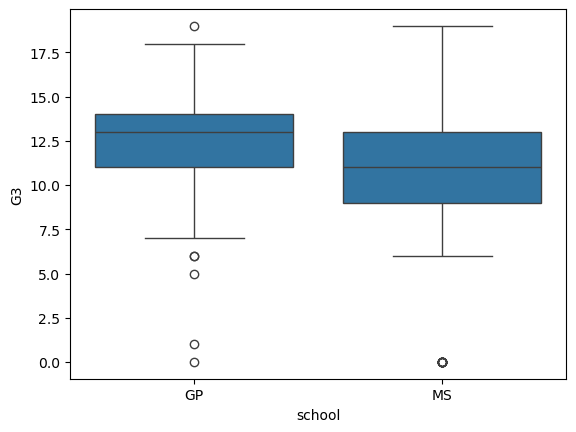

In [7]:
sns.boxplot(x="school",y="G3",data=df)

F-statistic: 10.962308407124874
P-value: 0.0009815287061373291
We reject the null hypothesis


<Axes: xlabel='sex', ylabel='G3'>

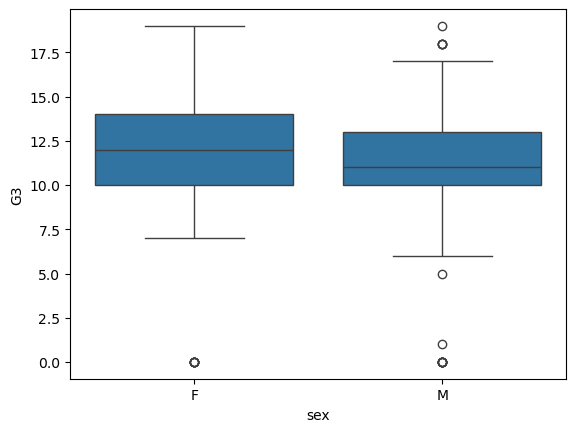

In [10]:
from scipy.stats import f_oneway

female_g3 = df[df['sex'] == 'F']['G3']

male_g3 = df[df['sex'] == 'M']['G3']

f_statistics, p_value = f_oneway(female_g3, male_g3)

print(f'F-statistic: {f_statistics}')

print(f'P-value: {p_value}')

if p_value > 0.05:
    print("We accept the null hypothesis")
else:
    print("We reject the null hypothesis")
    
sns.boxplot(x="sex",y="G3",data=df)

In [14]:
cor = df['age'].corr(df['G3'])
if abs(cor)>0.5 :
    print("there is a strong correltion between age and G3")
elif abs(cor) >0.3:
    print("there is a moderate correlation between age and G3")
else:
    print("there is weak correlation")
cor

there is weak correlation


-0.10650539063847862

<Axes: xlabel='age', ylabel='G3'>

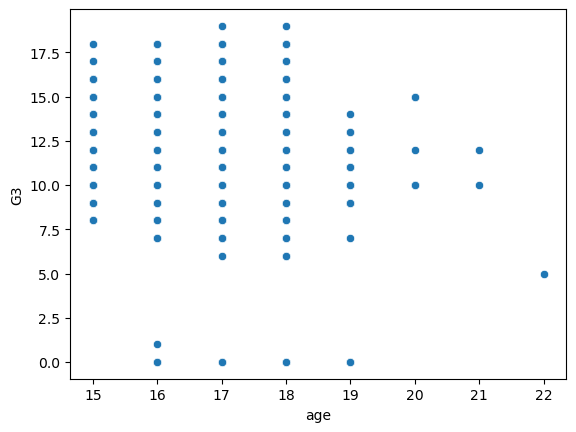

In [13]:
sns.scatterplot(x='age',y='G3',data=df)

In [15]:
categorical_columns = []
numerical_columns = []

for column in df.columns:
    if df[column].nunique() <= 5:
        categorical_columns.append(column)
    else:
        numerical_columns.append(column)

print("Categorical variables:", len(categorical_columns))
print(categorical_columns)

print("\nNumerical variables:", len(numerical_columns))
print(numerical_columns)

Categorical variables: 28
['school', 'sex', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu', 'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health']

Numerical variables: 5
['age', 'absences', 'G1', 'G2', 'G3']


In [16]:
from scipy.stats import f_oneway

categorical_columns = [
    'school', 'sex', 'address', 'famsize', 'Pstatus',
    'Medu', 'Fedu', 'Mjob', 'Fjob', 'reason', 'guardian',
    'traveltime', 'studytime', 'failures', 'schoolsup',
    'famsup', 'paid', 'activities', 'nursery', 'higher',
    'internet', 'romantic', 'famrel', 'freetime', 'goout',
    'Dalc', 'Walc', 'health'
]

def categorical_f_test(df, categorical_columns, target='G3'):
    
    for column in categorical_columns:
        
        groups = [
            group[target].dropna()
            for _, group in df.groupby(column)
        ]
        
        f_statistic, p_value = f_oneway(*groups)
        
        print(f"\nFeature: {column}")
        print(f"F-statistic: {f_statistic:.4f}")
        print(f"P-value: {p_value:.4f}")
        
        if p_value > 0.05:
            print("Conclusion: Fail to reject the null hypothesis.")
            print("There is no statistically significant difference in G3 between groups.")
        else:
            print("Conclusion: Reject the null hypothesis.")
            print("There is a statistically significant difference in G3 between groups.")

categorical_f_test(df, categorical_columns)


Feature: school
F-statistic: 56.8907
P-value: 0.0000
Conclusion: Reject the null hypothesis.
There is a statistically significant difference in G3 between groups.

Feature: sex
F-statistic: 10.9623
P-value: 0.0010
Conclusion: Reject the null hypothesis.
There is a statistically significant difference in G3 between groups.

Feature: address
F-statistic: 18.7079
P-value: 0.0000
Conclusion: Reject the null hypothesis.
There is a statistically significant difference in G3 between groups.

Feature: famsize
F-statistic: 1.3138
P-value: 0.2521
Conclusion: Fail to reject the null hypothesis.
There is no statistically significant difference in G3 between groups.

Feature: Pstatus
F-statistic: 0.0004
P-value: 0.9847
Conclusion: Fail to reject the null hypothesis.
There is no statistically significant difference in G3 between groups.

Feature: Medu
F-statistic: 10.7643
P-value: 0.0000
Conclusion: Reject the null hypothesis.
There is a statistically significant difference in G3 between groups.

F

In [20]:
from scipy.stats import f_oneway

categorical_columns = [
    'school', 'sex', 'address', 'famsize', 'Pstatus',
    'Medu', 'Fedu', 'Mjob', 'Fjob', 'reason', 'guardian',
    'traveltime', 'studytime', 'failures', 'schoolsup',
    'famsup', 'paid', 'activities', 'nursery', 'higher',
    'internet', 'romantic', 'famrel', 'freetime', 'goout',
    'Dalc', 'Walc', 'health'
]
rejected_columns = []
def categorical_f_test(df, categorical_columns, target='G3'):
    
    for column in categorical_columns:
        
        groups = [
            group[target].dropna()
            for _, group in df.groupby(column)
        ]
        
        f_statistic, p_value = f_oneway(*groups)
        
        if p_value < 0.05:
            rejected_columns.append(column)
            print(f"Feature: {column}")
            print(f"F-statistic: {f_statistic:.4f}")
            print(f"P-value: {p_value:.4f}")
            print("Conclusion: Reject the null hypothesis.")
            print("There is a statistically significant difference in G3 between groups.")
            print("-" * 50)
            

categorical_f_test(df, categorical_columns)
print(rejected_columns)

Feature: school
F-statistic: 56.8907
P-value: 0.0000
Conclusion: Reject the null hypothesis.
There is a statistically significant difference in G3 between groups.
--------------------------------------------------
Feature: sex
F-statistic: 10.9623
P-value: 0.0010
Conclusion: Reject the null hypothesis.
There is a statistically significant difference in G3 between groups.
--------------------------------------------------
Feature: address
F-statistic: 18.7079
P-value: 0.0000
Conclusion: Reject the null hypothesis.
There is a statistically significant difference in G3 between groups.
--------------------------------------------------
Feature: Medu
F-statistic: 10.7643
P-value: 0.0000
Conclusion: Reject the null hypothesis.
There is a statistically significant difference in G3 between groups.
--------------------------------------------------
Feature: Fedu
F-statistic: 8.2234
P-value: 0.0000
Conclusion: Reject the null hypothesis.
There is a statistically significant difference in G3 betw

In [19]:
def get_non_categorical_columns(df, categorical_columns):
    
    non_categorical_columns = [
        column for column in df.columns
        if column not in categorical_columns
    ]
    
    return non_categorical_columns


non_categorical_columns = get_non_categorical_columns(
    df, categorical_columns
)

print("Non-Categorical Features:")
print(non_categorical_columns)

print("\nTotal:", len(non_categorical_columns))

Non-Categorical Features:
['age', 'absences', 'G1', 'G2', 'G3']

Total: 5


In [22]:
new_df = df[['school', 'sex', 'address', 'Medu', 'Fedu', 'Mjob', 'Fjob', 'reason', 'traveltime', 'studytime', 'failures', 'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health','age', 'absences', 'G1', 'G2', 'G3'
]]

In [23]:
new_df

,school,sex,address,Medu,Fedu,Mjob,Fjob,reason,traveltime,studytime,...,freetime,goout,Dalc,Walc,health,age,absences,G1,G2,G3
0,GP,F,U,4,4,at_home,teacher,course,2,2,...,3,4,1,1,3,18,4,0,11,11
1,GP,F,U,1,1,at_home,other,course,1,2,...,3,3,1,1,3,17,2,9,11,11
2,GP,F,U,1,1,at_home,other,other,1,2,...,3,2,2,3,3,15,6,12,13,12
3,GP,F,U,4,2,health,services,home,1,3,...,2,2,1,1,5,15,0,14,14,14
4,GP,F,U,3,3,other,other,home,1,2,...,3,2,1,2,5,16,0,11,13,13
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
644,MS,F,R,2,3,services,other,course,1,3,...,4,2,1,2,5,19,4,10,11,10
645,MS,F,U,3,1,teacher,services,course,1,2,...,3,4,1,1,1,18,4,15,15,16
646,MS,F,U,1,1,other,other,course,2,2,...,1,1,1,1,5,18,6,11,12,9
647,MS,M,U,3,1,services,services,course,2,1,...,4,5,3,4,2,17,6,10,10,10
